# Assignment 2: Transfer Learning Across Two Datasets

**Name:** Matt Hunter

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [5]:

!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Skipping, found downloaded files in "./fire-dataset" (use force=True to force download)
fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [6]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

In [14]:
class_counts = {}
for images, labels in train_raw_fire:
    for label in labels.numpy():
        class_name = class_names_fire[label]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1

for name, count in class_counts.items():
    print(f"{name}: {count} images")

fire_images: 538 images
non_fire_images: 162 images


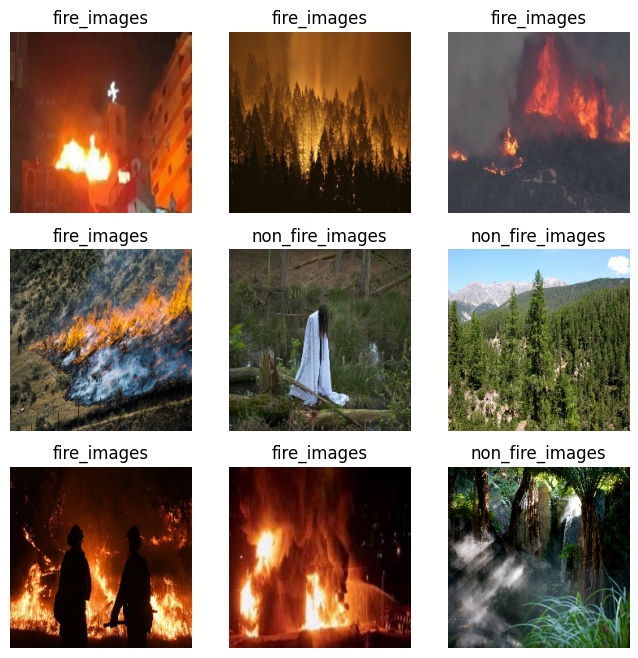

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
for images, labels in train_raw_fire.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names_fire[labels[i]])
        plt.axis("off")
plt.show()

In [ ]:
# Your exploration here

#After taking a look at the data we are using for this assignment we are able to see there are two class names that will be the output.
#They are fire_images and non_fire_images.
#We are able to see that with the training data, there are 538 fire images and 162 non fire images.
#Because the data has a lot more images for fire images and less that are non fire, we should split the data by using stratify or random shuffling.


*What did you notice about this dataset? Does it change how you'll approach the next steps?*

I noticed that the data has an imbalance of images between the two classes meaning we should use stratify or random shuffling with a seed which is what was done above when loading.


## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [19]:
# Preprocess the data here

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def preprocess_mobilenet(image, label):
    return preprocess_input(image), label

train_ds_mobilenet = train_raw_fire.map(preprocess_mobilenet)
val_ds_mobilenet = val_raw_fire.map(preprocess_mobilenet)

def preprocess_test_mobilenet(image, label):
    return preprocess_input(image), label

test_ds_mobilenet = test_raw_fire.map(preprocess_test_mobilenet)

In [20]:
# Build your model here

base_model_mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model_mobilenet.trainable = False  # Freeze the base

x = base_model_mobilenet.output
x = GlobalAveragePooling2D()(x)
output = Dense(1, activation='sigmoid')(x)

mobilenet_model = Model(inputs=base_model_mobilenet.input, outputs=output)
mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
# Compile your model here

mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


## 1D — Train and Evaluate

In [23]:
# Train your model here

mobilenet_history = mobilenet_model.fit(
    train_ds_mobilenet,
    validation_data=val_ds_mobilenet,
    epochs=5
)


Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.6657 - loss: 0.6389 - val_accuracy: 0.8345 - val_loss: 0.3752
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9243 - loss: 0.2310 - val_accuracy: 0.9640 - val_loss: 0.1761
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.9571 - loss: 0.1414 - val_accuracy: 0.9784 - val_loss: 0.1147
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9686 - loss: 0.1131 - val_accuracy: 0.9856 - val_loss: 0.0998
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9757 - loss: 0.0937 - val_accuracy: 0.9784 - val_loss: 0.0847


In [24]:
# Report validation and test accuracy here

val_loss, val_acc = mobilenet_model.evaluate(val_ds_mobilenet)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

test_loss, test_acc = mobilenet_model.evaluate(test_ds_mobilenet)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9640 - loss: 0.1038
Validation Accuracy: 96.40%
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.9750 - loss: 0.0916
Test Accuracy: 97.50%


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


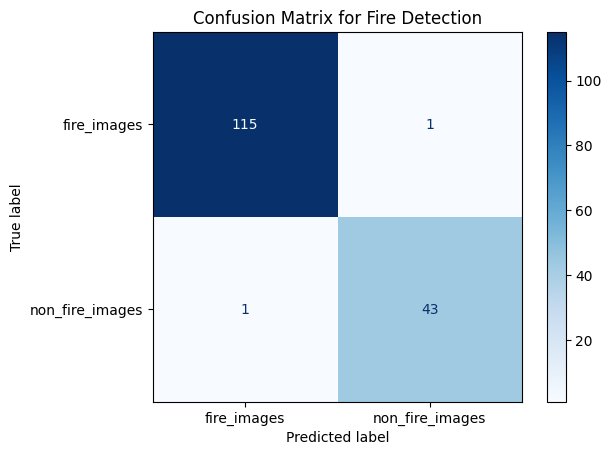

In [31]:
# Build your confusion matrix here

y_true = []
y_pred = []

for images, labels in test_ds_mobilenet:
    preds = mobilenet_model.predict(images)
    predicted_classes = (preds > 0.5).astype("int32").flatten()
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_fire)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Fire Detection")
plt.show()

*Your answer:*

In this context, missing a real fire, false negative, is much more costly than classifing a non fire image as a fire. If there really is a fire and the label gave a false negative meaning there it was labeled as a non fire, people's lives could be in danger and because of that, it would make sense to lower the threshold to make it harder for the model to produce false negative.


---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [32]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [33]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

Highway: 1765 images
HerbaceousVegetation: 2143 images
Industrial: 1753 images
SeaLake: 2085 images
River: 1697 images
PermanentCrop: 1743 images
Residential: 2114 images
Forest: 2082 images
Pasture: 1417 images
AnnualCrop: 2101 images


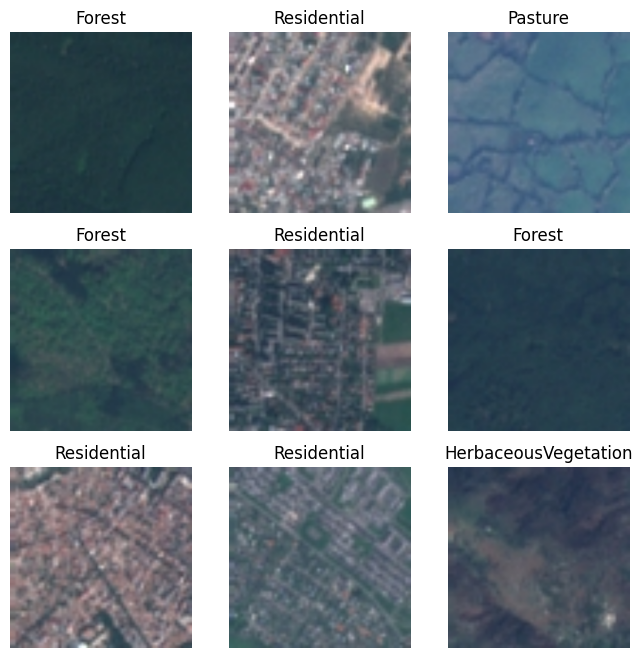

In [35]:
class_counts = {}
for images, labels in train_raw_sat:
    for label in labels.numpy():
        class_name = class_names_sat[label]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1

for name, count in class_counts.items():
    print(f"{name}: {count} images")


plt.figure(figsize=(8, 8))
for images, labels in train_raw_sat.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names_sat[labels[i]])
        plt.axis("off")
plt.show()

In [36]:
# Preprocess the data here

def preprocess_mobilenet(image, label):
    return preprocess_input(image), label

train_ds_mobilenet_sat = train_raw_sat.map(preprocess_mobilenet)
val_ds_mobilenet_sat = val_raw_sat.map(preprocess_mobilenet)

def preprocess_test_mobilenet(image, label):
    return preprocess_input(image), label

test_ds_mobilenet_sat = test_raw_sat.map(preprocess_test_mobilenet)

In [37]:
# Build your model here

base_model_mobilenet_sat = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model_mobilenet_sat.trainable = False

x = base_model_mobilenet_sat.output
x = GlobalAveragePooling2D()(x)
output = Dense(10, activation='softmax')(x)

mobilenet_model_sat = Model(inputs=base_model_mobilenet_sat.input, outputs=output)
mobilenet_model_sat.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [38]:
# Compile your model here

mobilenet_model_sat.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## 2C — Train and Evaluate

In [39]:
# Train your model here

mobilenet_history_sat = mobilenet_model_sat.fit(
    train_ds_mobilenet_sat,
    validation_data=val_ds_mobilenet_sat,
    epochs=5
)


Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 1040s 2s/step - accuracy: 0.8831 - loss: 0.3621 - val_accuracy: 0.9281 - val_loss: 0.2221
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 1044s 2s/step - accuracy: 0.9359 - loss: 0.1935 - val_accuracy: 0.9373 - val_loss: 0.1934
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 971s 2s/step - accuracy: 0.9483 - loss: 0.1578 - val_accuracy: 0.9331 - val_loss: 0.1901
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 997s 2s/step - accuracy: 0.9541 - loss: 0.1383 - val_accuracy: 0.9316 - val_loss: 0.1967
Epoch 5/5
 80/591 ━━━━━━━━━━━━━━━━━━━━ 11:42 1s/step - accuracy: 0.9580 - loss: 0.1228

KeyboardInterrupt: 

In [40]:
# Report validation and test accuracy here

val_loss, val_acc = mobilenet_model_sat.evaluate(val_ds_mobilenet_sat)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

test_loss, test_acc = mobilenet_model_sat.evaluate(test_ds_mobilenet_sat)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

127/127 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.9408 - loss: 0.1837
Validation Accuracy: 94.08%
127/127 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.9395 - loss: 0.1791
Test Accuracy: 93.95%


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

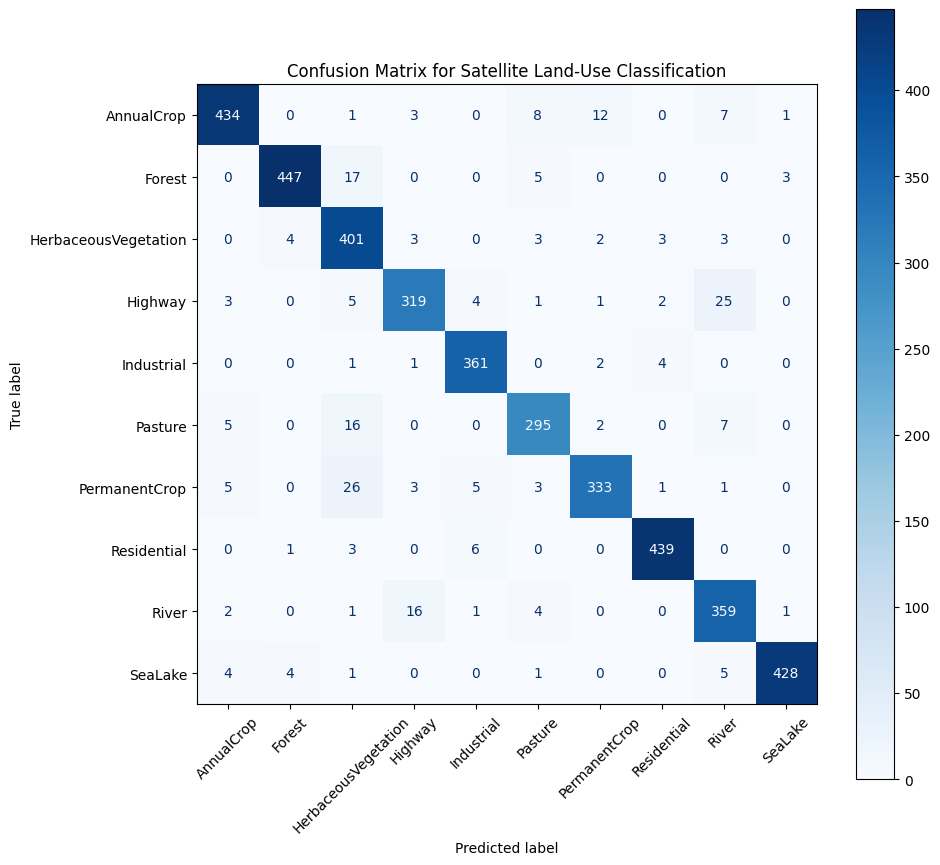

In [41]:
# Build your confusion matrix here

y_true = []
y_pred = []

for images, labels in test_ds_mobilenet_sat:
    preds = mobilenet_model_sat.predict(images)
    predicted_classes = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_sat)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Satellite Land-Use Classification")
plt.show()


*Your answer:*

The class that was most confused was HerbaceousVegeterian for PermanentCrop and this makes sense because from a satellite image like we used, they both show very similar features like all green, open layouts. It is hard to tell the difference based off the quality of the images.


---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | 96.40% | 94.08% |
| Test Accuracy | 97.50% | 93.95% |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*

1. The Fire data set is a better match for moile net since most of those images are taken from an eye level or a little above while the EuroSAT is a bigger mismatch because those images are taken from above looking down on the land (satellite). Also we had a better accuracy with the Fire dataset proving the mobilenet is a great match for it.

2. Yes, I think there is room for improvement for each dataset if we could adjust part of the model because it would allow the models to learn specific features better by unfreezing part of the model. This would matter more for the EuroSAT data because the images are taken from a satellite view and not the normal ground level view so it would help the model recognize patterns better for these types of images.


---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*

The class imbalance in the Fire dataset required us to use random shuffling during data splitting to ensure both classes were properly represented as we were given. In Part 1 we used 1 output neuron with a sigmoid activation and binary cross-entropy because it had only two classes, but Part 2 we used 10 output neurons with softmax and sparse categorical cross-entropy for multiple classes. The difference exists because for binary classification we are only outputting one probability, fire or no fire. For multiple classification for the EuroSAT data, we have to make sure all the probabilities for all classes adds uo to 100%. A pretrained model's usefulness depends on how well its original training matches our target, not just how good the model itself is. We can see this from our results, because the ground-level Fire dataset achieved higher accuracy than the top-down satellite dataset because ImageNet consists of similar ground-level photos.

---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.